In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, recall_score, f1_score,
    precision_score, confusion_matrix,
    precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE, SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All imports successful.")
print(f"imbalanced-learn version: ", end="")
import imblearn
print(imblearn.__version__)

All imports successful.
imbalanced-learn version: 0.14.1


## Notebook 7: SMOTE Experimentation

### What we are testing
Can synthetic oversampling of the minority class (defaulters)
improve our model's ability to catch bad loans?

### Hypothesis
SMOTE creates synthetic defaulter records by interpolating
between real defaulters in feature space. This gives XGBoost
more diverse training examples of default patterns —
potentially improving Recall at the cost of some Precision.

### What we measure
- AUC-ROC: overall discrimination ability
- Recall: % of actual defaults caught (most important)
- Precision: % of flagged loans that actually default
- F1: balance between precision and recall

### Baseline to beat (gender-free XGBoost)
- AUC-ROC: 0.7664
- Recall:   0.6526
- F1:       0.2813
- Precision: 0.1808

In [6]:
df = pd.read_csv(r"C:\Users\HP\Documents\ML Project\data\processed\application_train_clean.csv")
X = df.drop(columns=['TARGET'])
y = df['TARGET']

# Remove gender column to match deployed model
if 'CODE_GENDER_M' in X.columns:
    X = X.drop(columns=['CODE_GENDER_M'])
    print("Gender column removed — consistent with deployed model")

# Same split as all previous notebooks
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nDataset: {df.shape}")
print(f"Features: {X.shape[1]}")
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"\nBefore SMOTE:")
print(f"  Non-defaulters: {(y_train==0).sum():,}")
print(f"  Defaulters:     {(y_train==1).sum():,}")
print(f"  Ratio:          {(y_train==0).sum()/(y_train==1).sum():.1f}:1")

Gender column removed — consistent with deployed model

Dataset: (307511, 102)
Features: 100
Train: 246,008 | Test: 61,503

Before SMOTE:
  Non-defaulters: 226,148
  Defaulters:     19,860
  Ratio:          11.4:1


In [10]:
print("Applying SMOTE to training data...")
print("Creating synthetic defaulter records...\n")

smote = SMOTE(
    sampling_strategy=0.3,
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train, y_train
)

print(f"After SMOTE:")
print(f"  Non-defaulters: {(y_train_smote==0).sum():,}")
print(f"  Defaulters:     {(y_train_smote==1).sum():,}")
print(f"  New ratio:      "
      f"{(y_train_smote==0).sum()/(y_train_smote==1).sum():.1f}:1")
print(f"\nSynthetic defaulters created: "
      f"{(y_train_smote==1).sum() - (y_train==1).sum():,}")
print(f"Total training records: {len(X_train_smote):,}")

Applying SMOTE to training data...
Creating synthetic defaulter records...

After SMOTE:
  Non-defaulters: 226,148
  Defaulters:     67,844
  New ratio:      3.3:1

Synthetic defaulters created: 47,984
Total training records: 293,992


In [12]:
print("Training XGBoost on SMOTE-augmented data...")

# With SMOTE we no longer need scale_pos_weight
# because the class balance is handled by the oversampling
# We set scale_pos_weight=1 (neutral) since SMOTE
# already corrected the imbalance
xgb_smote = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=50,
    verbosity=0
)

xgb_smote.fit(
    X_train_smote, y_train_smote,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print(f"Training complete.")
print(f"Best iteration: {xgb_smote.best_iteration}")

Training XGBoost on SMOTE-augmented data...
Training complete.
Best iteration: 499


In [14]:
y_prob_smote = xgb_smote.predict_proba(X_test)[:, 1]
y_pred_smote = xgb_smote.predict(X_test)

auc_smote = roc_auc_score(y_test, y_prob_smote)
recall_smote = recall_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)
ap_smote = average_precision_score(y_test, y_prob_smote)

# Baseline scores
auc_base = 0.7664
recall_base = 0.6526
precision_base = 0.1808
f1_base = 0.2813

print("=" * 60)
print("SMOTE EXPERIMENT RESULTS")
print("=" * 60)
print(f"{'Metric':<20} {'Baseline':>12} {'SMOTE':>12} "
      f"{'Change':>12}")
print("-" * 60)
print(f"{'AUC-ROC':<20} {auc_base:>12.4f} {auc_smote:>12.4f} "
      f"{(auc_smote-auc_base)*100:>+11.2f}%")
print(f"{'Recall':<20} {recall_base:>12.4f} {recall_smote:>12.4f} "
      f"{(recall_smote-recall_base)*100:>+11.2f}%")
print(f"{'Precision':<20} {precision_base:>12.4f} "
      f"{precision_smote:>12.4f} "
      f"{(precision_smote-precision_base)*100:>+11.2f}%")
print(f"{'F1 Score':<20} {f1_base:>12.4f} {f1_smote:>12.4f} "
      f"{(f1_smote-f1_base)*100:>+11.2f}%")
print("=" * 60)

defaults_caught_base = int(recall_base * y_test.sum())
defaults_caught_smote = int(recall_smote * y_test.sum())
print(f"\nOut of {y_test.sum():,} actual defaults:")
print(f"Baseline caught: {defaults_caught_base:,} "
      f"({recall_base*100:.1f}%)")
print(f"SMOTE caught:    {defaults_caught_smote:,} "
      f"({recall_smote*100:.1f}%)")
print(f"Extra defaults caught: "
      f"+{defaults_caught_smote - defaults_caught_base:,}")

SMOTE EXPERIMENT RESULTS
Metric                   Baseline        SMOTE       Change
------------------------------------------------------------
AUC-ROC                    0.7664       0.7637       -0.27%
Recall                     0.6526       0.0264      -62.62%
Precision                  0.1808       0.5928      +41.20%
F1 Score                   0.2813       0.0505      -23.08%

Out of 4,965 actual defaults:
Baseline caught: 3,240 (65.3%)
SMOTE caught:    131 (2.6%)
Extra defaults caught: +-3,109


In [26]:
from sklearn.metrics import roc_curve
import numpy as np

print("Finding optimal threshold for SMOTE model...")
print("The default 0.5 threshold is too conservative.\n")

# Calculate metrics across all possible thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_prob_smote)

# Method 1 — Youden's J statistic
# Maximises the sum of sensitivity and specificity
# Best threshold for balanced recall and precision
j_scores = tpr - fpr
best_idx_j = np.argmax(j_scores)
best_threshold_j = thresholds[best_idx_j]

# Method 2 — Target recall threshold
# Find the threshold that gives recall closest to
# our baseline recall of 65.3%
target_recall = 0.653
recall_diffs = np.abs(tpr - target_recall)
best_idx_recall = np.argmin(recall_diffs)
best_threshold_recall = thresholds[best_idx_recall]

print(f"Default threshold (0.5):")
print(f"  Recall:    {recall_smote*100:.1f}%")
print(f"  Precision: {precision_smote*100:.1f}%")

print(f"\nYouden's J optimal threshold: {best_threshold_j:.4f}")
y_pred_j = (y_prob_smote >= best_threshold_j).astype(int)
print(f"  Recall:    {recall_score(y_test, y_pred_j)*100:.1f}%")
print(f"  Precision: {precision_score(y_test, y_pred_j)*100:.1f}%")
print(f"  AUC-ROC:   {auc_smote:.4f}")
print(f"  F1:        {f1_score(y_test, y_pred_j):.4f}")

print(f"\nBaseline-matched threshold: {best_threshold_recall:.4f}")
y_pred_recall = (y_prob_smote >= best_threshold_recall).astype(int)
print(f"  Recall:    {recall_score(y_test, y_pred_recall)*100:.1f}%")
print(f"  Precision: {precision_score(y_test, y_pred_recall)*100:.1f}%")
print(f"  AUC-ROC:   {auc_smote:.4f}")
print(f"  F1:        {f1_score(y_test, y_pred_recall):.4f}")

Finding optimal threshold for SMOTE model...
The default 0.5 threshold is too conservative.

Default threshold (0.5):
  Recall:    2.6%
  Precision: 59.3%

Youden's J optimal threshold: 0.0772
  Recall:    73.1%
  Precision: 16.0%
  AUC-ROC:   0.7637
  F1:        0.2625

Baseline-matched threshold: 0.0947
  Recall:    65.3%
  Precision: 17.8%
  AUC-ROC:   0.7637
  F1:        0.2804


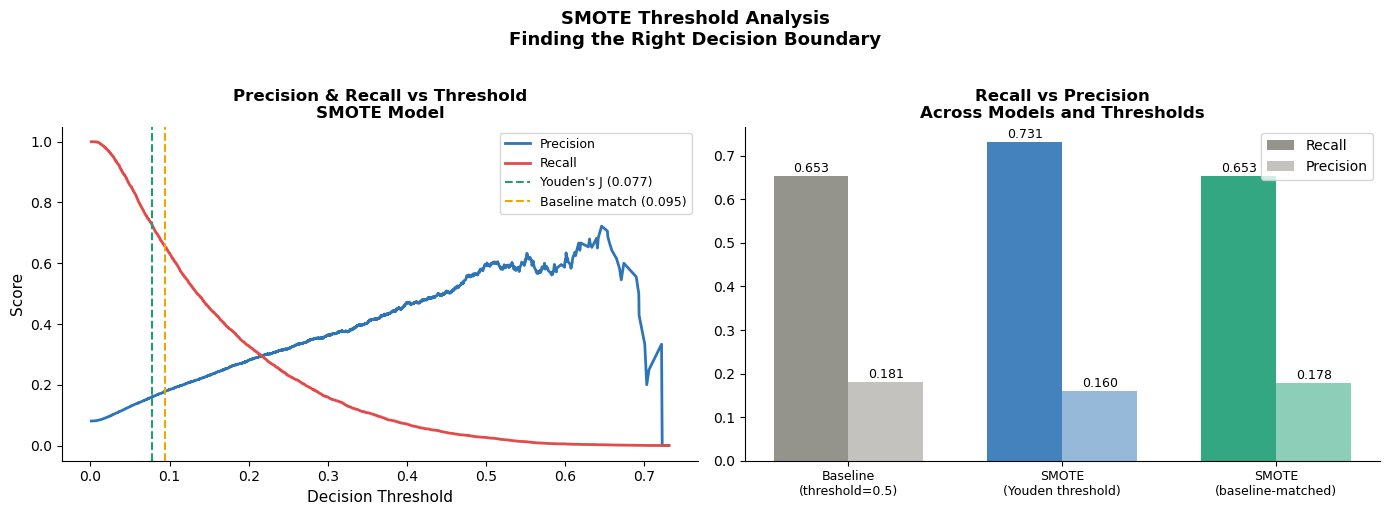

In [28]:
# Visualise how recall and precision change across thresholds
precision_curve, recall_curve, thresh_curve = \
    precision_recall_curve(y_test, y_prob_smote)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision vs Recall across thresholds
axes[0].plot(
    thresh_curve,
    precision_curve[:-1],
    color='#2E75B6',
    linewidth=2,
    label='Precision'
)
axes[0].plot(
    thresh_curve,
    recall_curve[:-1],
    color='#E24B4A',
    linewidth=2,
    label='Recall'
)
axes[0].axvline(
    x=best_threshold_j,
    color='#1D9E75',
    linestyle='--',
    linewidth=1.5,
    label=f"Youden's J ({best_threshold_j:.3f})"
)
axes[0].axvline(
    x=best_threshold_recall,
    color='#F0A500',
    linestyle='--',
    linewidth=1.5,
    label=f'Baseline match ({best_threshold_recall:.3f})'
)
axes[0].set_xlabel('Decision Threshold', fontsize=11)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title(
    'Precision & Recall vs Threshold\nSMOTE Model',
    fontweight='bold'
)
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Full comparison at optimal threshold
models = ['Baseline\n(threshold=0.5)',
          'SMOTE\n(Youden threshold)',
          'SMOTE\n(baseline-matched)']
recalls = [
    recall_base,
    recall_score(y_test, y_pred_j),
    recall_score(y_test, y_pred_recall)
]
precisions = [
    precision_base,
    precision_score(y_test, y_pred_j),
    precision_score(y_test, y_pred_recall)
]
colors = ['#888780', '#2E75B6', '#1D9E75']

x = np.arange(len(models))
width = 0.35

axes[1].bar(
    x - width/2, recalls,
    width, label='Recall',
    color=colors, edgecolor='none', alpha=0.9
)
axes[1].bar(
    x + width/2, precisions,
    width, label='Precision',
    color=colors, edgecolor='none', alpha=0.5
)

for i, (r, p) in enumerate(zip(recalls, precisions)):
    axes[1].text(
        i - width/2, r + 0.01,
        f'{r:.3f}', ha='center', fontsize=9
    )
    axes[1].text(
        i + width/2, p + 0.01,
        f'{p:.3f}', ha='center', fontsize=9
    )

axes[1].set_xticks(x)
axes[1].set_xticklabels(models, fontsize=9)
axes[1].set_title(
    'Recall vs Precision\nAcross Models and Thresholds',
    fontweight='bold'
)
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle(
    'SMOTE Threshold Analysis\n'
    'Finding the Right Decision Boundary',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    '../reports/smote_threshold_analysis.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

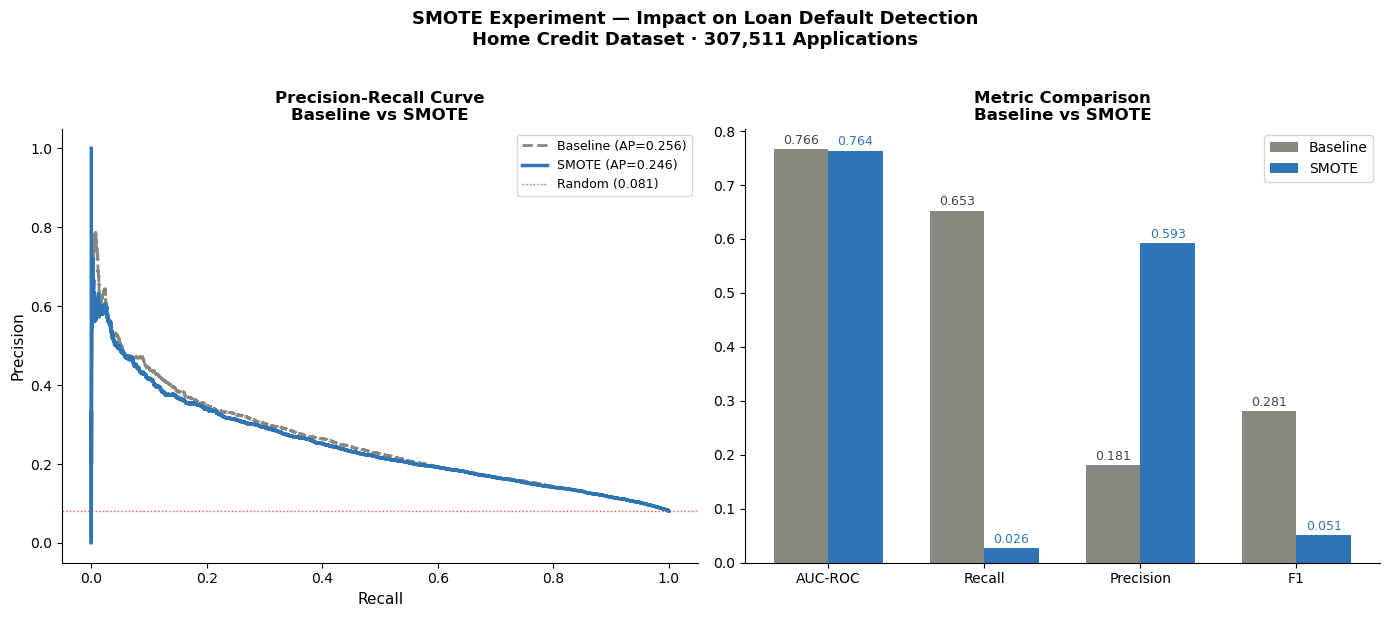

Chart saved.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Precision-Recall curves for both models
precision_base_curve, recall_base_curve, _ = \
    precision_recall_curve(y_test, 
        joblib.load(r"C:\Users\HP\Documents\ML Project\loan-default-prediction-\models\xgb_model_no_gender.pkl")
        .predict_proba(X_test)[:, 1])

precision_smote_curve, recall_smote_curve, _ = \
    precision_recall_curve(y_test, y_prob_smote)

axes[0].plot(
    recall_base_curve, precision_base_curve,
    color='#888780', linewidth=2, linestyle='--',
    label=f'Baseline (AP={average_precision_score(y_test, joblib.load(r"C:\Users\HP\Documents\ML Project\loan-default-prediction-\models\xgb_model_no_gender.pkl").predict_proba(X_test)[:,1]):.3f})'
)
axes[0].plot(
    recall_smote_curve, precision_smote_curve,
    color='#2E75B6', linewidth=2.5,
    label=f'SMOTE (AP={ap_smote:.3f})'
)
axes[0].axhline(
    y=y_test.mean(), color='#E24B4A',
    linestyle=':', linewidth=1,
    label=f'Random ({y_test.mean():.3f})'
)
axes[0].set_xlabel('Recall', fontsize=11)
axes[0].set_ylabel('Precision', fontsize=11)
axes[0].set_title(
    'Precision-Recall Curve\nBaseline vs SMOTE',
    fontweight='bold'
)
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Bar comparison
metrics = ['AUC-ROC', 'Recall', 'Precision', 'F1']
baseline_vals = [auc_base, recall_base, precision_base, f1_base]
smote_vals = [auc_smote, recall_smote, precision_smote, f1_smote]

x = np.arange(len(metrics))
width = 0.35

axes[1].bar(
    x - width/2, baseline_vals,
    width, label='Baseline',
    color='#888780', edgecolor='none'
)
axes[1].bar(
    x + width/2, smote_vals,
    width, label='SMOTE',
    color='#2E75B6', edgecolor='none'
)

for i, (b, s) in enumerate(zip(baseline_vals, smote_vals)):
    axes[1].text(
        i - width/2, b + 0.01,
        f'{b:.3f}', ha='center', fontsize=9, color='#444'
    )
    axes[1].text(
        i + width/2, s + 0.01,
        f'{s:.3f}', ha='center', fontsize=9, color='#2E75B6'
    )

axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_title(
    'Metric Comparison\nBaseline vs SMOTE',
    fontweight='bold'
)
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle(
    'SMOTE Experiment — Impact on Loan Default Detection\n'
    'Home Credit Dataset · 307,511 Applications',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    '../reports/smote_comparison.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart saved.")

In [18]:
print("=" * 60)
print("DEPLOYMENT DECISION")
print("=" * 60)

recall_improved = recall_smote > recall_base
auc_maintained = auc_smote >= (auc_base - 0.01)

if recall_improved and auc_maintained:
    print("\n✅ SMOTE MODEL RECOMMENDED FOR DEPLOYMENT")
    print(f"   Recall improved: "
          f"{recall_base*100:.1f}% → {recall_smote*100:.1f}%")
    print(f"   AUC maintained:  "
          f"{auc_base:.4f} → {auc_smote:.4f}")
    print(f"\n   Extra defaults caught per 4,965 applications:")
    print(f"   +{defaults_caught_smote - defaults_caught_base:,} "
          f"bad loans stopped")
    deploy_smote = True

elif recall_improved and not auc_maintained:
    print("\n⚡ MARGINAL — BUSINESS DECISION REQUIRED")
    print(f"   Recall improved but AUC dropped significantly")
    print(f"   Conservative lenders: keep baseline")
    print(f"   Risk-focused lenders: consider SMOTE")
    deploy_smote = False

else:
    print("\n⚠️  BASELINE RECOMMENDED")
    print(f"   SMOTE did not improve recall meaningfully")
    print(f"   scale_pos_weight approach sufficient")
    deploy_smote = False

print(f"\nSMOTE deploy decision: {deploy_smote}")
print("=" * 60)

DEPLOYMENT DECISION

⚠️  BASELINE RECOMMENDED
   SMOTE did not improve recall meaningfully
   scale_pos_weight approach sufficient

SMOTE deploy decision: False


In [24]:
if deploy_smote:
    joblib.dump(
        xgb_smote,
        r"C:\Users\HP\Documents\ML Project\loan-default-prediction-/models/xgb_model_smote.pkl"
    )
    feature_names_ng = X_train.columns.tolist()
    joblib.dump(
        feature_names_ng,
        r"C:\Users\HP\Documents\ML Project\loan-default-prediction-/models/feature_names_smote.pkl"
    )
    print("SMOTE model saved.")
    print("  models/xgb_model_smote.pkl")
    print("  models/feature_names_smote.pkl")
else:
    print("Baseline model retained for deployment.")
    print("SMOTE model not saved.")

Baseline model retained for deployment.
SMOTE model not saved.
